In [1]:
#imports 
%load_ext autoreload
%autoreload 2

import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

from diffusion_sae.model import import_model, get_block, get_activation


/opt/pytorch/lib64/python3.13/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [ ]:
from diffusion_sae.model import generate, import_model



In [ ]:
pipe = import_model("CompVis/stable-diffusion-v1-4")


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


device(type='cuda', index=0)

In [29]:
out = generate(pipe, "A cat wearing a superhero cape in van gogh style")

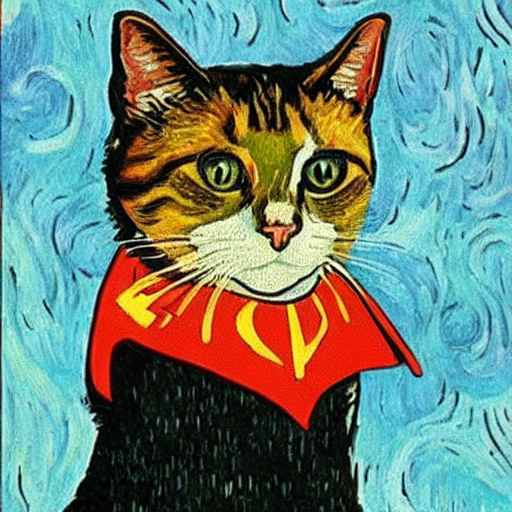

In [30]:
out[-1][1]

In [2]:
import matplotlib.pyplot as plt


ModuleNotFoundError: No module named 'matplotlib'

In [1]:
import torch

ModuleNotFoundError: No module named 'torch'

In [2]:


pipe = StableDiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4",
    torch_dtype=torch.float32,
)
pipe = pipe.to("mps")
pipe.enable_attention_slicing()  # recommended on MPS to avoid memory spikes
print("Stable Diffusion 1.4 loaded:", type(pipe).__name__, "on", pipe.device)

Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 24.33it/s]


Stable Diffusion 1.4 loaded: StableDiffusionPipeline on mps:0


In [24]:
from tqdm import tqdm 

for i in tqdm(range(1000)): 
    pass

100%|██████████| 1000/1000 [00:00<00:00, 10180349.51it/s]


In [3]:
pipe = import_model("CompVis/stable-diffusion-v1-4")


Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 35.25it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [15]:
activations = get_activation(pipe, ['unet.up_blocks.3.attentions.2'], "cat")

In [21]:
len(activations['unet.up_blocks.3.attentions.2'])

31

****Encode Text****


In [19]:
act = activations['unet.up_blocks.3.attentions.2'][0][0]
act.shape


torch.Size([320, 64, 64])

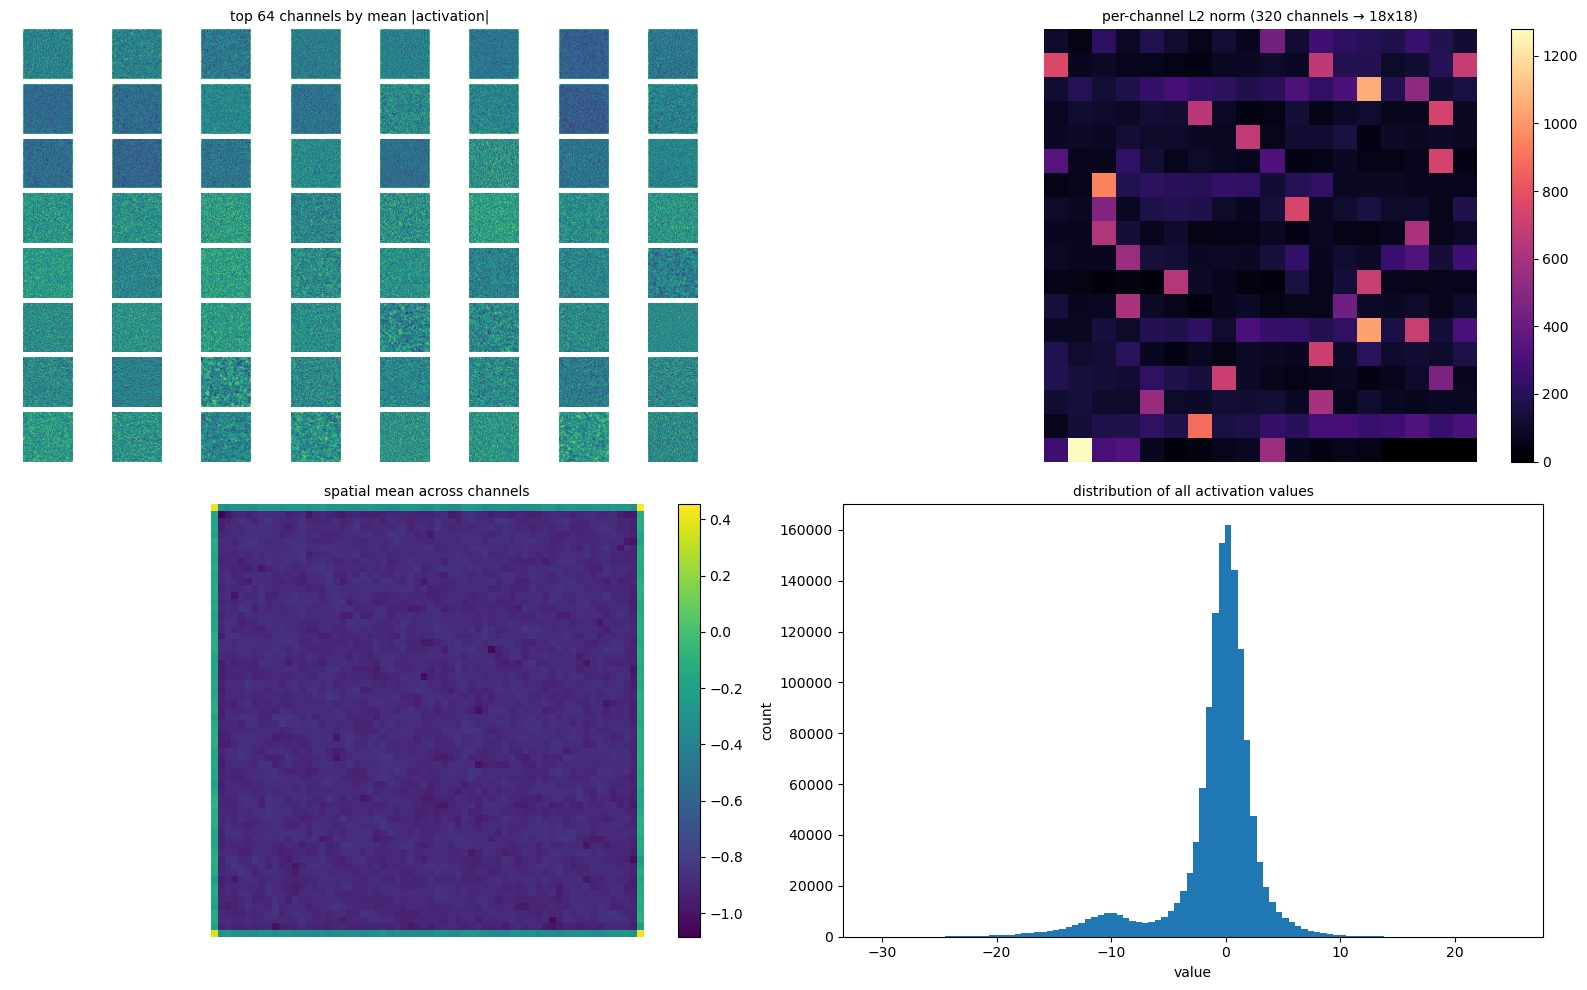

In [18]:
import math

# act: [C, H, W], H == W
act = act.detach().cpu().float()
C, H, W = act.shape

fig = plt.figure(figsize=(16, 10))

# --- 1. Grid of most-active channel maps ---
n = min(64, C)
idx = act.flatten(1).abs().mean(1).argsort(descending=True)[:n]
sel = act[idx]
gcols = 8
grows = math.ceil(n / gcols)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

sub = gs[0, 0].subgridspec(grows, gcols)
for k in range(n):
    ax = fig.add_subplot(sub[k // gcols, k % gcols])
    ax.imshow(sel[k], cmap="viridis")
    ax.axis("off")
fig.add_subplot(gs[0, 0]).set_title(f"top {n} channels by mean |activation|", fontsize=10)
fig.axes[-1].axis("off")

# --- 2. Per-channel norm heatmap ---
ax2 = fig.add_subplot(gs[0, 1])
summary = act.flatten(1).norm(dim=1)            # [C]
side = math.ceil(math.sqrt(C))
pad = side * side - C
summary_grid = torch.cat([summary, torch.zeros(pad)]).reshape(side, side)
im2 = ax2.imshow(summary_grid, cmap="magma")
ax2.set_title(f"per-channel L2 norm ({C} channels → {side}x{side})", fontsize=10)
ax2.axis("off")
fig.colorbar(im2, ax=ax2, fraction=0.046)

# --- 3. Spatial mean across channels ---
ax3 = fig.add_subplot(gs[1, 0])
im3 = ax3.imshow(act.mean(0), cmap="viridis")
ax3.set_title("spatial mean across channels", fontsize=10)
ax3.axis("off")
fig.colorbar(im3, ax=ax3, fraction=0.046)

# --- 4. Distribution of activation values ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(act.flatten().numpy(), bins=100)
ax4.set_title("distribution of all activation values", fontsize=10)
ax4.set_xlabel("value"); ax4.set_ylabel("count")

plt.tight_layout()
plt.show()

In [30]:
import torch, math
import matplotlib.pyplot as plt
from PIL import Image

device = pipe.device
prompt = "a painting of a cat"
height = width = 512
num_inference_steps = 30
guidance_scale = 7.5



In [45]:
a_cat = embed("a cat")
photo = embed("a photo of a cat")
painting = embed("a painting of a cat")
house = embed("a house")
a_cat.shape, photo.shape, painting.shape

(torch.Size([1, 77, 768]), torch.Size([1, 77, 768]), torch.Size([1, 77, 768]))

In [46]:
import torch
import torch.nn.functional as F

prompts = {
    "a cat":            a_cat,
    "a photo of a cat": photo,
    "a painting of a cat": painting,
    "a house": house
}

# --- collapse each [1, 77, 768] sequence to a single [768] vector ---
# Mask out padding tokens so the ~70 padding positions don't dominate the mean.
def pooled(x, text):
    tok = pipe.tokenizer(text, padding="max_length",
                         max_length=pipe.tokenizer.model_max_length,
                         truncation=True, return_tensors="pt")
    mask = tok.attention_mask[0].to(x.device).bool()   # [77], True = real token
    real = x[0][mask]                                   # [n_real, 768]
    return real.mean(dim=0)                             # [768]

vecs = {name: pooled(emb, name) for name, emb in prompts.items()}

# --- pairwise cosine similarity matrix ---
names = list(vecs)
M = torch.stack([vecs[n] for n in names])               # [3, 768]
M = F.normalize(M, dim=-1)
sim = M @ M.T                                           # [3, 3]
print("Cosine similarity (masked mean-pooled):\n")
header = " " * 22 + "".join(f"{n[:16]:>18}" for n in names)
print(header)
for i, n in enumerate(names):
    row = "".join(f"{sim[i, j]:18.4f}" for j in range(len(names)))
    print(f"{n[:20]:<22}" + row)

Cosine similarity (masked mean-pooled):

                                   a cat  a photo of a cat  a painting of a            a house
a cat                             1.0000            0.7703            0.7565            0.7836
a photo of a cat                  0.7703            1.0000            0.7347            0.6588
a painting of a cat               0.7565            0.7347            1.0000            0.6508
a house                           0.7836            0.6588            0.6508            1.0000


In [31]:
#uses CLIP text encoder to get text embeddings for the prompt and an empty string(uncond part)

def embed(text):
    tk = pipe.tokenizer(text, padding="max_length",
                        max_length=pipe.tokenizer.model_max_length,
                        truncation=True, return_tensors="pt")
    with torch.no_grad():
        return pipe.text_encoder(tk.input_ids.to(device))[0]
text_embeddings = torch.cat([embed([""]), embed(prompt)])

print(text_embeddings.shape)

torch.Size([2, 77, 768])


In [32]:
 # --- initial latents + scheduler ---

generator = torch.Generator(device="cpu").manual_seed(40)
latents = torch.randn((1, pipe.unet.config.in_channels, height // 8, width // 8),
                      generator=generator).to(device)

print(f'Latents shape: {latents.shape}, range: ({latents.min():.2f}, {latents.max():.2f})')
pipe.scheduler.set_timesteps(num_inference_steps)
latents = latents * pipe.scheduler.init_noise_sigma


Latents shape: torch.Size([1, 4, 64, 64]), range: (-3.69, 3.69)


In [33]:

# --- helper: decode a latent to a PIL image via the VAE ---
@torch.no_grad()
def decode(lat):
    img = pipe.vae.decode(lat / pipe.vae.config.scaling_factor).sample
    img = (img / 2 + 0.5).clamp(0, 1)[0].cpu().permute(1, 2, 0).float().numpy()
    return Image.fromarray((img * 255).round().astype("uint8"))


In [34]:
frames = [("start (pure noise)", decode(latents))]      # the starting point


In [35]:

# --- denoising loop ---
for i, t in enumerate(pipe.scheduler.timesteps):
    latent_model_input = pipe.scheduler.scale_model_input(torch.cat([latents] * 2), t)
    with torch.no_grad():
        noise_pred = pipe.unet(latent_model_input, t,
                               encoder_hidden_states=text_embeddings).sample
    nu, nt = noise_pred.chunk(2)
    noise_pred = nu + guidance_scale * (nt - nu)          # classifier-free guidance
    latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample
    frames.append((f"step {i+1}", decode(latents)))       # decode current latent



print(f"captured {len(frames)} frames (start + {num_inference_steps} steps)")


captured 32 frames (start + 30 steps)


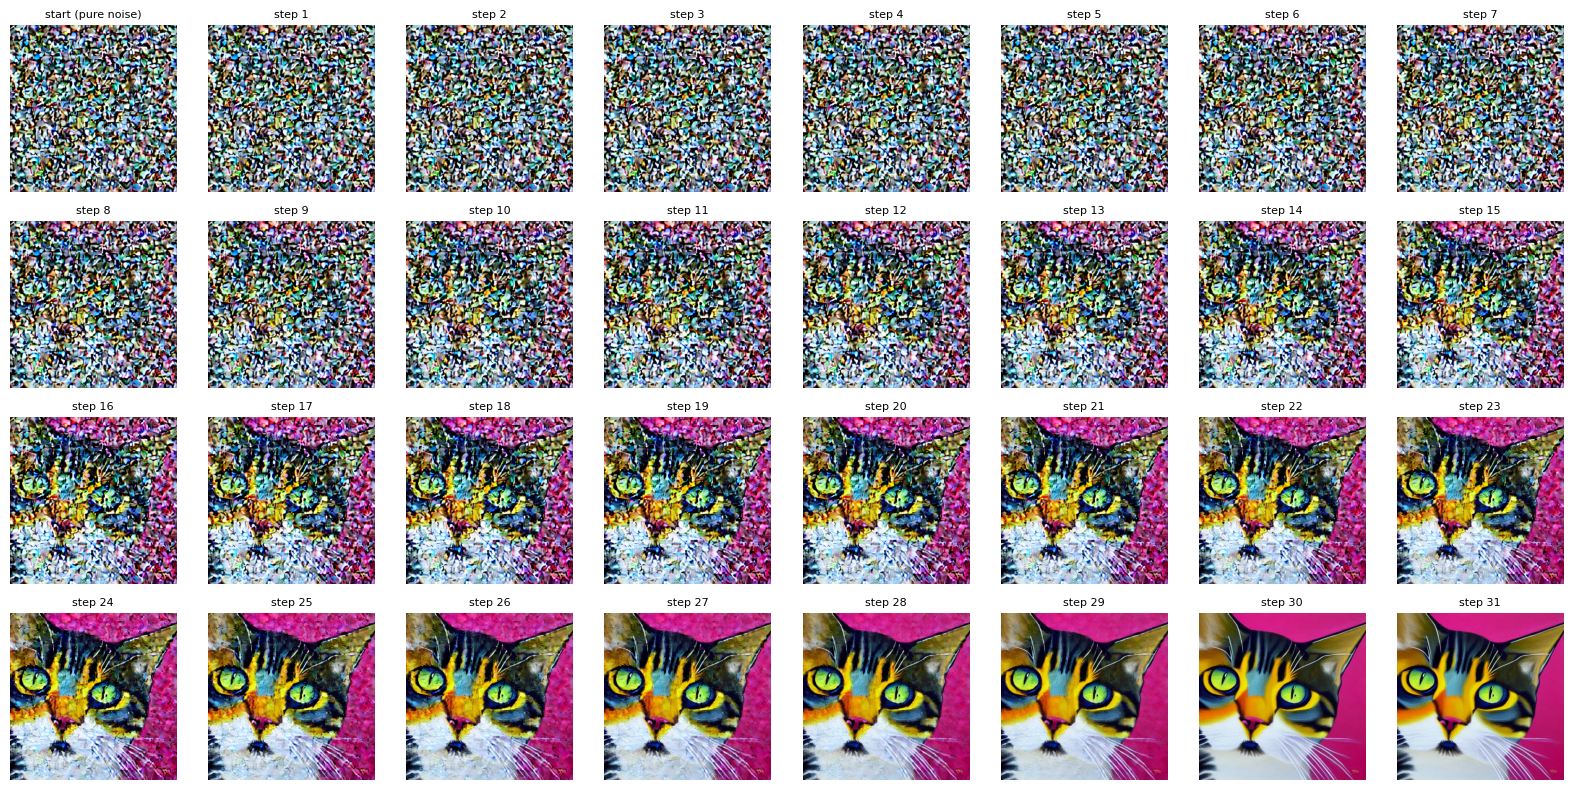

saved denoising_trajectory.png


In [36]:
# --- visualize as a grid ---
cols = 8
rows = math.ceil(len(frames) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
for ax in axes.flat:
    ax.axis("off")
for ax, (title, im) in zip(axes.flat, frames):
    ax.imshow(im)
    ax.set_title(title, fontsize=8)
plt.tight_layout()
plt.savefig("denoising_trajectory.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved denoising_trajectory.png")

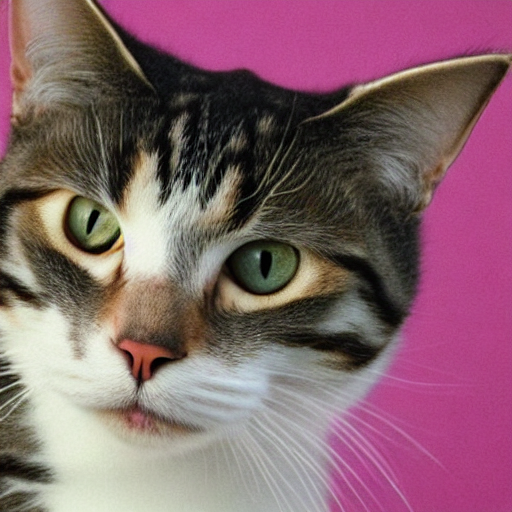

In [22]:
frames[-1][1] 

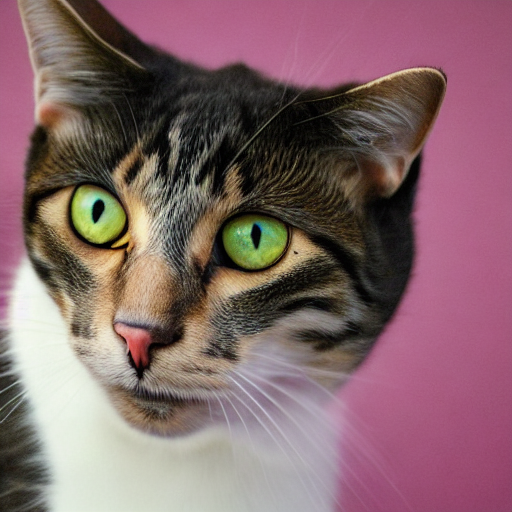

In [29]:
frames[-1][1] 

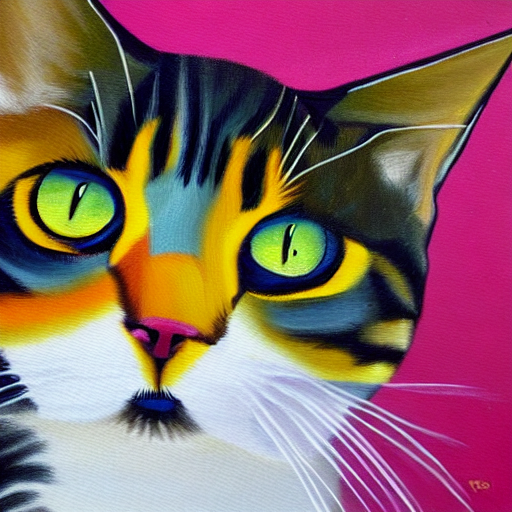

In [37]:
frames[-1][1] 